Dataset shape after cleaning: (32561, 16)
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country  income age_group  
0          2174             0              40  United-State

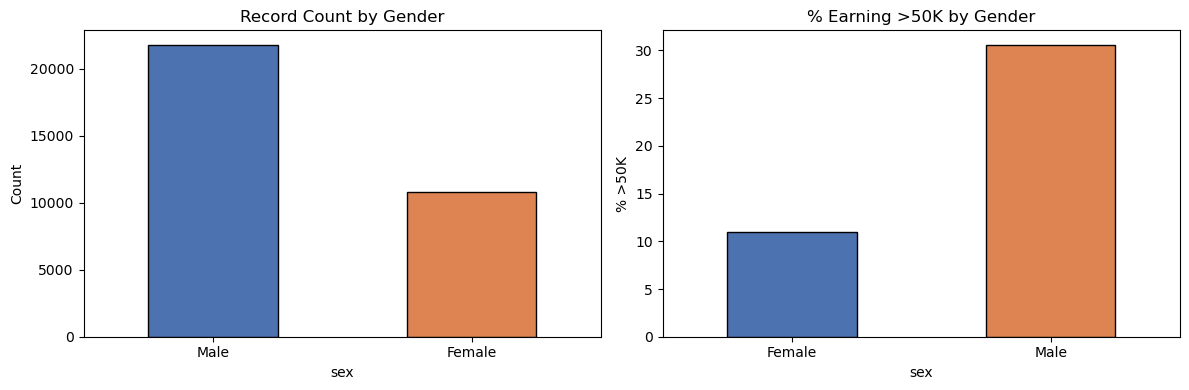


--- Race Distribution ---
race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

% earning >50K by race:
race
Amer-Indian-Eskimo    11.58
Asian-Pac-Islander    26.56
Black                 12.39
Other                  9.23
White                 25.59
Name: income, dtype: float64


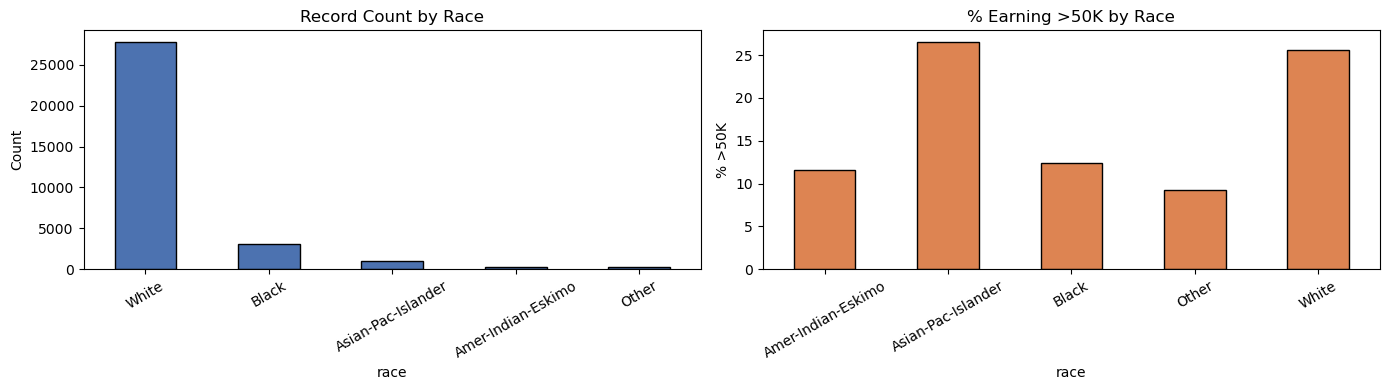

<ipython-input-2-716d398ad71c>:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_income  = df.groupby('age_group')['income'].mean() * 100



--- Age Group Distribution ---
age_group
≤25      6411
26-35    8514
36-45    8009
46-55    5538
56+      4089
Name: count, dtype: int64

% earning >50K by age group:
age_group
≤25       1.78
26-35    18.69
36-45    34.64
46-55    39.83
56+      28.27
Name: income, dtype: float64


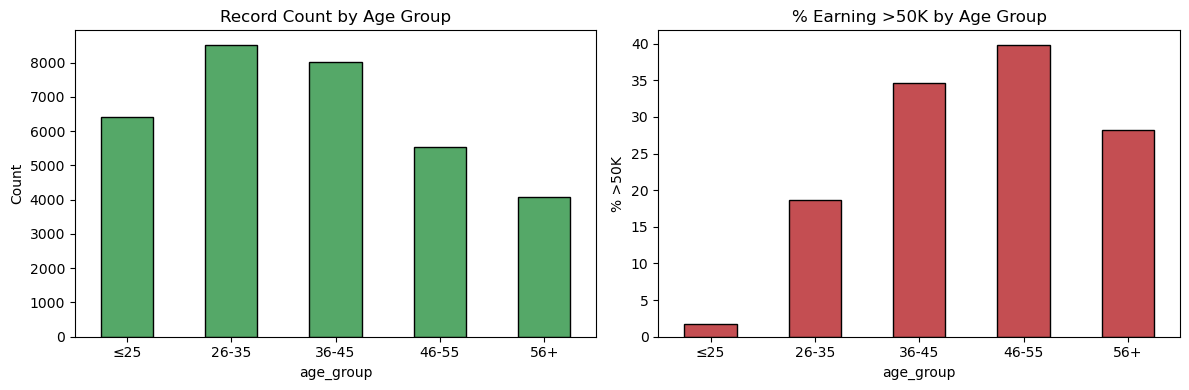


--------------------------------------------------
UNDERREPRESENTATION ANALYSIS
--------------------------------------------------

>> Gender  (balanced share = 50.0% each)
Group                       Count   Share % Status
------------------------------------------------------------
Male                        21790    66.92%  OK
Female                      10771    33.08%  UNDERREPRESENTED

>> Race  (balanced share = 20.0% each)
Group                       Count   Share % Status
------------------------------------------------------------
White                       27816    85.43%  OK
Black                        3124     9.59%  UNDERREPRESENTED
Asian-Pac-Islander           1039     3.19%  UNDERREPRESENTED
Amer-Indian-Eskimo            311     0.96%  UNDERREPRESENTED
Other                         271     0.83%  UNDERREPRESENTED

>> Age Group  (balanced share = 20.0% each)
Group                       Count   Share % Status
------------------------------------------------------------

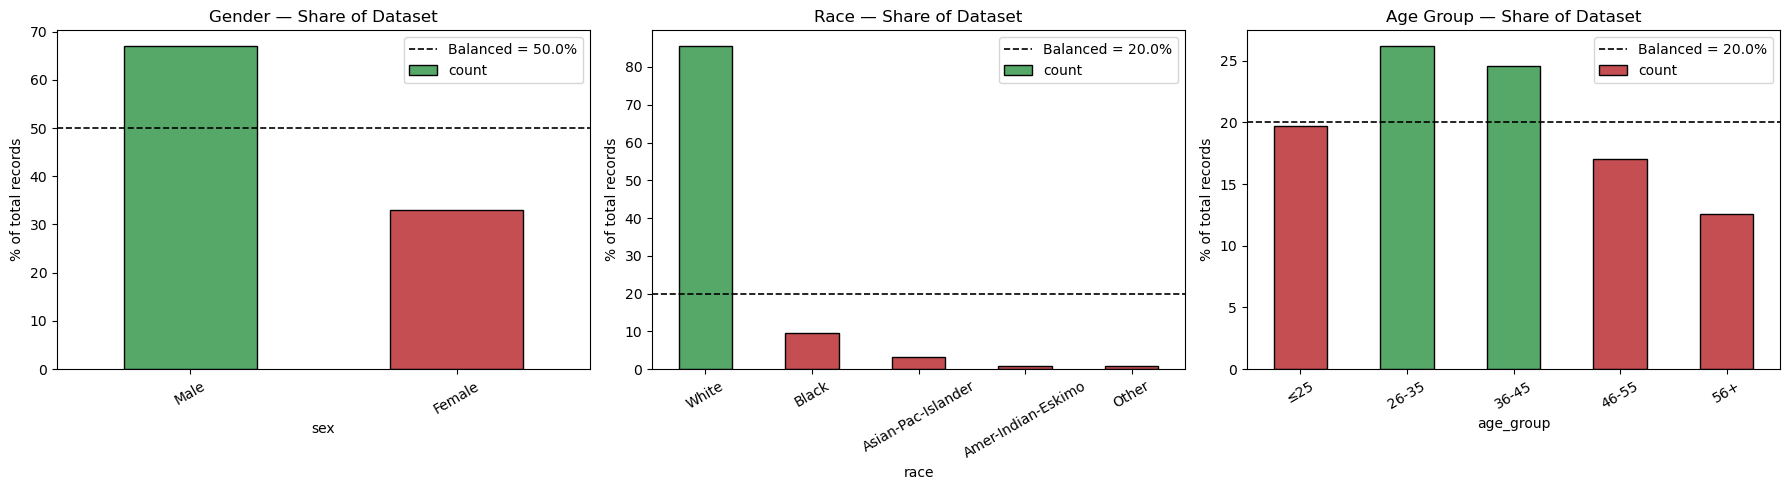


2. TRAIN MODEL (baseline — accuracy only)

Logistic Regression Accuracy: 0.8263
Decision Tree Accuracy:      0.8560

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

       <=50K       0.85      0.94      0.89      7417
        >50K       0.72      0.46      0.56      2352

    accuracy                           0.83      9769
   macro avg       0.78      0.70      0.73      9769
weighted avg       0.82      0.83      0.81      9769

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      7417
        >50K       0.78      0.56      0.65      2352

    accuracy                           0.86      9769
   macro avg       0.82      0.76      0.78      9769
weighted avg       0.85      0.86      0.85      9769


3. FAIRNESS CHECK — Metrics by Demographic Group

[Logistic Regression]

>> Fairness by Gender
 Group  Support  Precision  Recall    

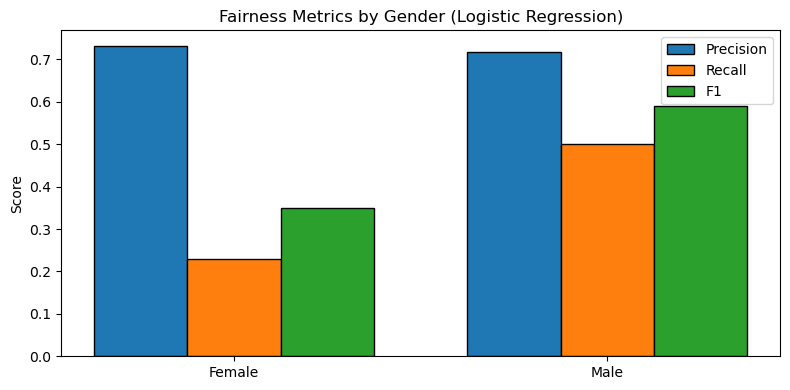

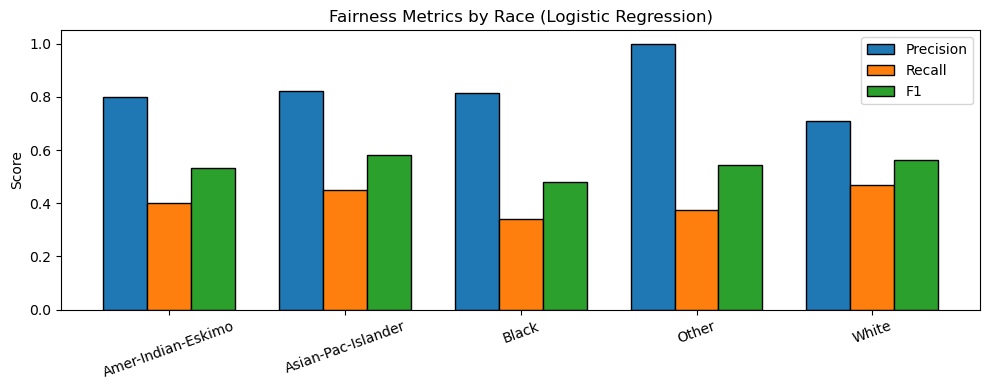


4. MITIGATION — Sample Reweighting
Weight map (gender): {'Female': np.float64(1.505), 'Male': np.float64(0.7488)}

Reweighted LR Accuracy: 0.8242 (baseline: 0.8263)

--- Reweighted LR Classification Report ---
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      7417
        >50K       0.72      0.45      0.55      2352

    accuracy                           0.82      9769
   macro avg       0.78      0.69      0.72      9769
weighted avg       0.81      0.82      0.81      9769


[After Reweighting]

>> Fairness by Gender
 Group  Support  Precision  Recall     F1
Female     3199     0.7826  0.2514 0.3805
  Male     6570     0.7121  0.4799 0.5734

>> Fairness by Race
             Group  Support  Precision  Recall     F1
Amer-Indian-Eskimo      100     0.8000  0.4000 0.5333
Asian-Pac-Islander      303     0.8537  0.4268 0.5691
             Black      967     0.8679  0.3566 0.5055
             Other       73     1.0000  0.5000 0.6667
 

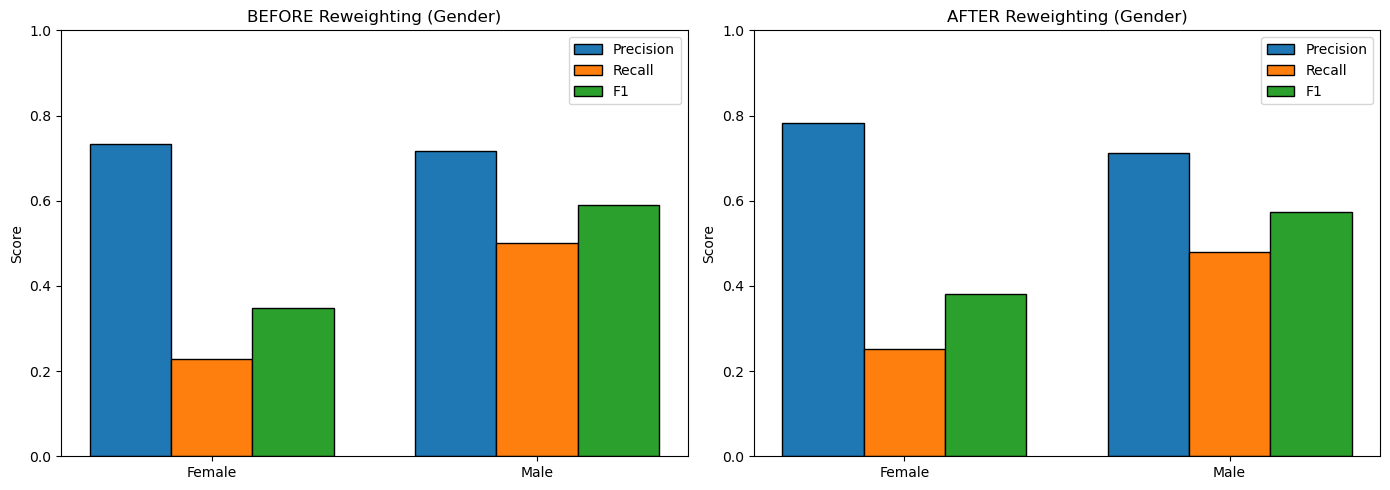


--- Before vs After Reweighting (Gender) ---
 Group  Prec_Before  Rec_Before  F1_Before  Prec_After  Rec_After  F1_After
Female       0.7321      0.2291     0.3489      0.7826     0.2514    0.3805
  Male       0.7168      0.5000     0.5891      0.7121     0.4799    0.5734

5. DISCUSSION — Accuracy vs Fairness

Should we prioritize accuracy or fairness?

In a high-stakes decision system (hiring, lending, criminal justice), optimizing
for raw accuracy alone can perpetuate historical biases because the model learns
patterns from data that already reflects societal inequalities. For instance, in
the Adult dataset the baseline model achieves higher recall for Males than Females,
meaning it is better at identifying high-income individuals when they are male.

Reweighting the training data to give underrepresented groups (Female) more
influence slightly adjusts these gaps. The overall accuracy may drop marginally,
but the recall disparity between genders narrows, producing a fairer model.

I

In [2]:
# ============================================================
# AI Fairness Hands-On — Adult Census Income Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

# ────────────────────────────────────────────────────────────
# 0.  LOAD & CLEAN
# ────────────────────────────────────────────────────────────

cols = ['age','workclass','fnlwgt','education','education_num',
        'marital_status','occupation','relationship','race','sex',
        'capital_gain','capital_loss','hours_per_week','native_country','income']

df = pd.read_csv('adult.data', header=None, names=cols,
                 na_values=' ?', skipinitialspace=True)

df.dropna(inplace=True)

# Binary target: 1 = >50K ("hired / high-income"), 0 = <=50K
df['income'] = df['income'].map({'>50K': 1, '<=50K': 0})

# Age groups for fairness analysis
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 25, 35, 45, 55, 100],
                         labels=['≤25','26-35','36-45','46-55','56+'])

print(f"Dataset shape after cleaning: {df.shape}")
print(df.head())

# ============================================================
# 1.  EDA — Protected Attributes
# ============================================================

print("\n" + "="*60)
print("1. EDA — PROTECTED ATTRIBUTES")
print("="*60)

# --- Gender ---
gender_counts = df['sex'].value_counts()
gender_income  = df.groupby('sex')['income'].mean() * 100
print("\n--- Gender Distribution ---")
print(gender_counts)
print(f"\n% earning >50K by gender:\n{gender_income.round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gender_counts.plot.bar(ax=axes[0], color=['#4c72b0','#dd8452'], edgecolor='black')
axes[0].set_title('Record Count by Gender')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

gender_income.plot.bar(ax=axes[1], color=['#4c72b0','#dd8452'], edgecolor='black')
axes[1].set_title('% Earning >50K by Gender')
axes[1].set_ylabel('% >50K')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('eda_gender.png', dpi=150)
plt.show()

# --- Race ---
race_counts = df['race'].value_counts()
race_income  = df.groupby('race')['income'].mean() * 100
print("\n--- Race Distribution ---")
print(race_counts)
print(f"\n% earning >50K by race:\n{race_income.round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
race_counts.plot.bar(ax=axes[0], color='#4c72b0', edgecolor='black')
axes[0].set_title('Record Count by Race')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

race_income.plot.bar(ax=axes[1], color='#dd8452', edgecolor='black')
axes[1].set_title('% Earning >50K by Race')
axes[1].set_ylabel('% >50K')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('eda_race.png', dpi=150)
plt.show()

# --- Age Group ---
age_counts = df['age_group'].value_counts().sort_index()
age_income  = df.groupby('age_group')['income'].mean() * 100
print("\n--- Age Group Distribution ---")
print(age_counts)
print(f"\n% earning >50K by age group:\n{age_income.round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
age_counts.plot.bar(ax=axes[0], color='#55a868', edgecolor='black')
axes[0].set_title('Record Count by Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

age_income.plot.bar(ax=axes[1], color='#c44e52', edgecolor='black')
axes[1].set_title('% Earning >50K by Age Group')
axes[1].set_ylabel('% >50K')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('eda_age.png', dpi=150)
plt.show()

# --- Quantitative Underrepresentation Check ---
print("\n" + "-"*50)
print("UNDERREPRESENTATION ANALYSIS")
print("-"*50)

def check_underrepresentation(counts, attr_name):
    """Flag any group whose share is below the balanced share (1/k)."""
    total = counts.sum()
    n_groups = len(counts)
    balanced_share = 100 / n_groups            # what each group would have if perfectly balanced
    print(f"\n>> {attr_name}  (balanced share = {balanced_share:.1f}% each)")
    print(f"{'Group':<25} {'Count':>7} {'Share %':>9} {'Status'}")
    print("-" * 60)
    for group, cnt in counts.items():
        share = cnt / total * 100
        flag = "UNDERREPRESENTED" if share < balanced_share else "OK"
        print(f"{str(group):<25} {cnt:>7} {share:>8.2f}%  {flag}")

check_underrepresentation(gender_counts, 'Gender')
check_underrepresentation(race_counts,   'Race')
check_underrepresentation(age_counts,    'Age Group')

# Combined bar chart — share vs balanced threshold
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (counts, title) in zip(axes, [(gender_counts, 'Gender'),
                                       (race_counts, 'Race'),
                                       (age_counts, 'Age Group')]):
    shares = counts / counts.sum() * 100
    balanced = 100 / len(counts)
    colors = ['#c44e52' if s < balanced else '#55a868' for s in shares]
    shares.plot.bar(ax=ax, color=colors, edgecolor='black')
    ax.axhline(balanced, color='black', linestyle='--', linewidth=1.2,
               label=f'Balanced = {balanced:.1f}%')
    ax.set_title(f'{title} — Share of Dataset')
    ax.set_ylabel('% of total records')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('underrepresentation.png', dpi=150)
plt.show()

# ============================================================
# 2.  TRAIN MODEL — No Fairness, Just Accuracy
# ============================================================

print("\n" + "="*60)
print("2. TRAIN MODEL (baseline — accuracy only)")
print("="*60)

# Encode categoricals
cat_cols = ['workclass','education','marital_status','occupation',
            'relationship','race','sex','native_country']

df_model = df.copy()
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c])
    le_dict[c] = le

feature_cols = ['age','workclass','fnlwgt','education','education_num',
                'marital_status','occupation','relationship','race','sex',
                'capital_gain','capital_loss','hours_per_week','native_country']

X = df_model[feature_cols]
y = df_model['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features for Logistic Regression convergence
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Keep the original (non-encoded) protected attributes aligned with test set
test_idx = X_test.index
sex_test       = df.loc[test_idx, 'sex'].values
race_test      = df.loc[test_idx, 'race'].values
age_group_test = df.loc[test_idx, 'age_group'].values

# Logistic Regression (on scaled data)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# Decision Tree (unscaled is fine)
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"\nLogistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Decision Tree Accuracy:      {accuracy_score(y_test, y_pred_dt):.4f}")

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['<=50K','>50K']))

print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt, target_names=['<=50K','>50K']))

# ============================================================
# 3.  CHECK FAIRNESS ACROSS GROUPS
# ============================================================

print("\n" + "="*60)
print("3. FAIRNESS CHECK — Metrics by Demographic Group")
print("="*60)

def fairness_report(y_true, y_pred, groups, group_name):
    """Print precision / recall / f1 for each subgroup."""
    unique = np.unique(groups)
    rows = []
    for g in unique:
        mask = (groups == g)
        if mask.sum() == 0:
            continue
        p = precision_score(y_true[mask], y_pred[mask], zero_division=0)
        r = recall_score(y_true[mask], y_pred[mask], zero_division=0)
        f = f1_score(y_true[mask], y_pred[mask], zero_division=0)
        rows.append({'Group': g, 'Support': mask.sum(),
                     'Precision': round(p,4), 'Recall': round(r,4),
                     'F1': round(f,4)})
    report = pd.DataFrame(rows)
    print(f"\n>> Fairness by {group_name}")
    print(report.to_string(index=False))
    return report

# Use Logistic Regression predictions for main fairness analysis
print("\n[Logistic Regression]")
rep_sex  = fairness_report(y_test.values, y_pred_lr, sex_test, 'Gender')
rep_race = fairness_report(y_test.values, y_pred_lr, race_test, 'Race')
rep_age  = fairness_report(y_test.values, y_pred_lr, age_group_test, 'Age Group')

# Plot fairness comparison — Gender
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(rep_sex))
w = 0.25
ax.bar(x_pos - w, rep_sex['Precision'], w, label='Precision', edgecolor='black')
ax.bar(x_pos,     rep_sex['Recall'],    w, label='Recall',    edgecolor='black')
ax.bar(x_pos + w, rep_sex['F1'],        w, label='F1',        edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(rep_sex['Group'])
ax.set_title('Fairness Metrics by Gender (Logistic Regression)')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('fairness_gender.png', dpi=150)
plt.show()

# Plot fairness comparison — Race
fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(len(rep_race))
ax.bar(x_pos - w, rep_race['Precision'], w, label='Precision', edgecolor='black')
ax.bar(x_pos,     rep_race['Recall'],    w, label='Recall',    edgecolor='black')
ax.bar(x_pos + w, rep_race['F1'],        w, label='F1',        edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(rep_race['Group'], rotation=20)
ax.set_title('Fairness Metrics by Race (Logistic Regression)')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('fairness_race.png', dpi=150)
plt.show()

# ============================================================
# 4.  MITIGATION — Reweighting Underrepresented Groups
# ============================================================

print("\n" + "="*60)
print("4. MITIGATION — Sample Reweighting")
print("="*60)

# Compute sample weights inversely proportional to group frequency (by sex)
train_idx = X_train.index
sex_train = df.loc[train_idx, 'sex'].values

sex_classes, sex_counts_arr = np.unique(sex_train, return_counts=True)
total = len(sex_train)
weight_map = {c: total / (len(sex_classes) * cnt)
              for c, cnt in zip(sex_classes, sex_counts_arr)}
sample_weights = np.array([weight_map[s] for s in sex_train])

print("Weight map (gender):", {k: round(v, 4) for k, v in weight_map.items()})

# Retrain Logistic Regression with sample weights
lr_fair = LogisticRegression(max_iter=1000, random_state=42)
lr_fair.fit(X_train_sc, y_train, sample_weight=sample_weights)
y_pred_fair = lr_fair.predict(X_test_sc)

print(f"\nReweighted LR Accuracy: {accuracy_score(y_test, y_pred_fair):.4f} "
      f"(baseline: {accuracy_score(y_test, y_pred_lr):.4f})")

print("\n--- Reweighted LR Classification Report ---")
print(classification_report(y_test, y_pred_fair, target_names=['<=50K','>50K']))

# Fairness after mitigation
print("\n[After Reweighting]")
rep_sex_fair  = fairness_report(y_test.values, y_pred_fair, sex_test, 'Gender')
rep_race_fair = fairness_report(y_test.values, y_pred_fair, race_test, 'Race')

# Side-by-side comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
ax = axes[0]
x_pos = np.arange(len(rep_sex))
ax.bar(x_pos - w, rep_sex['Precision'], w, label='Precision', edgecolor='black')
ax.bar(x_pos,     rep_sex['Recall'],    w, label='Recall',    edgecolor='black')
ax.bar(x_pos + w, rep_sex['F1'],        w, label='F1',        edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(rep_sex['Group'])
ax.set_title('BEFORE Reweighting (Gender)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()

# After
ax = axes[1]
x_pos = np.arange(len(rep_sex_fair))
ax.bar(x_pos - w, rep_sex_fair['Precision'], w, label='Precision', edgecolor='black')
ax.bar(x_pos,     rep_sex_fair['Recall'],    w, label='Recall',    edgecolor='black')
ax.bar(x_pos + w, rep_sex_fair['F1'],        w, label='F1',        edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(rep_sex_fair['Group'])
ax.set_title('AFTER Reweighting (Gender)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('mitigation_comparison.png', dpi=150)
plt.show()

# Numeric comparison table
print("\n--- Before vs After Reweighting (Gender) ---")
comparison = rep_sex[['Group','Precision','Recall','F1']].copy()
comparison.columns = ['Group','Prec_Before','Rec_Before','F1_Before']
comparison['Prec_After']  = rep_sex_fair['Precision'].values
comparison['Rec_After']   = rep_sex_fair['Recall'].values
comparison['F1_After']    = rep_sex_fair['F1'].values
print(comparison.to_string(index=False))

# ============================================================
# 5.  DISCUSSION
# ============================================================

print("\n" + "="*60)
print("5. DISCUSSION — Accuracy vs Fairness")
print("="*60)

discussion = """
Should we prioritize accuracy or fairness?

In a high-stakes decision system (hiring, lending, criminal justice), optimizing
for raw accuracy alone can perpetuate historical biases because the model learns
patterns from data that already reflects societal inequalities. For instance, in
the Adult dataset the baseline model achieves higher recall for Males than Females,
meaning it is better at identifying high-income individuals when they are male.

Reweighting the training data to give underrepresented groups (Female) more
influence slightly adjusts these gaps. The overall accuracy may drop marginally,
but the recall disparity between genders narrows, producing a fairer model.

In practice, neither extreme — pure accuracy nor pure fairness — is ideal.
A balanced approach considers:
  • The domain context (e.g., healthcare vs advertising).
  • Legal and ethical requirements (e.g., anti-discrimination laws).
  • Stakeholder impact — who is harmed by errors?
  • Transparent reporting of per-group metrics so decision-makers can
    evaluate trade-offs explicitly.

The best strategy is to treat fairness as a constraint: maximize accuracy
subject to acceptable fairness thresholds (e.g., equalized odds, demographic
parity), rather than treating it as an afterthought.
"""
print(discussion)